In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ngsolve import *
from ngsolve.webgui import Draw

In [2]:
import os
from pathlib import Path
import sys

sys.path.append(str(Path(os.getcwd()).parent / "src"))

import importlib
import utils
import active_gel_fem
import myosin_actin_gel_fem

importlib.reload(active_gel_fem)
importlib.reload(myosin_actin_gel_fem)
importlib.reload(utils)

from myosin_actin_gel_fem import MyosinActinGel1D, MyosinActinGel2D
from utils import tanh_source, rectangular_source

## Source terms

Define `S(x)` (actin source) and `m0(x)` (myosin target) as smooth bump profiles.
Both are NGSolve `CoefficientFunction`s, so they work directly in the FEM assembly.

In [3]:
# Central strip source — actin is produced in a band around x=0.5
S  = tanh_source(center=0.5, width=0.1, value=1, axis='x') + 0.1 

# Myosin target — elevated in the same band
m0 = tanh_source(center=0.5, width=0.1, value=1.0, axis='x')

Qsq = tanh_source(center=0.5, width=0.1, value=2.0, axis='x') - 1 

## 1D simulation

In [4]:
T   = 100
tau = 0.05

sim1d = MyosinActinGel1D(
    maxh  = 0.01,
    # mechanics
    gamma = 1.0,
    eta_1 = 1,
    eta_2 = 0.0,
    chi0  = 0.1,
    chi1  = 0.5,
    # nematic
    kappa = 1e-3,
    beta1 = 1.0,
    beta2 = 1.0,
    Qsq   = Qsq,
    # density / myosin
    S     = S,
    m0    = m0,
    k0    = 0.1,
    k1    = 1,
    k_m   = 1,
    D_rho = 1e-3,
    D_m   = 1e-3,
    # base
    k     = 0.5,
    D     = 1e-3,
    rho0  = 1.0,
)

sim1d.simulate(tend=T, tau=tau, save_interval=int(0.5/tau))
data1d = sim1d.export()

 42%|████▏     | 830/2000 [00:00<00:00, 4223.76it/s]

craete bilinearformapplication


100%|██████████| 2000/2000 [00:00<00:00, 4122.57it/s]


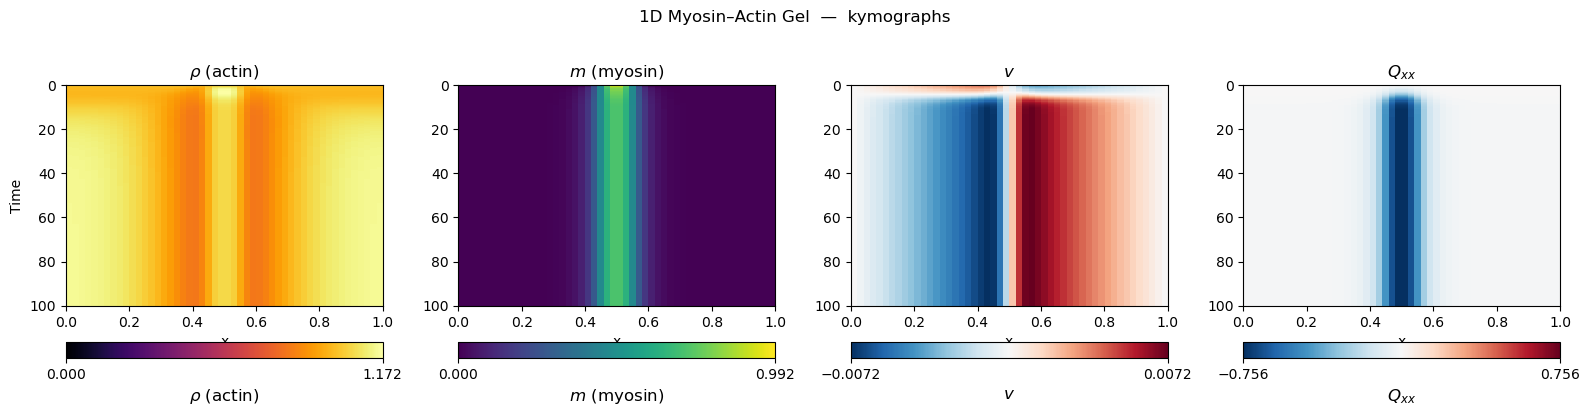

In [5]:
# Kymograph: rho, m, v, Q over time
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

fields = [
    (data1d['rho'], r'$\rho$ (actin)',   'inferno'),
    (data1d['m'],   r'$m$ (myosin)',     'viridis'),
    (data1d['v'],   r'$v$',              'RdBu_r'),
    (data1d['Q'],   r'$Q_{xx}$',         'RdBu_r'),
]

t_end = data1d['rho'].shape[0] * 0.5  # each saved frame = 0.5 time units

for ax, (field, title, cmap) in zip(axes, fields):
    vmax = np.max(np.abs(field))
    vmin = -vmax if cmap == 'RdBu_r' else 0
    im = ax.imshow(field, aspect='auto', interpolation='none',
                   origin='upper', cmap=cmap, extent=(0, 1, t_end, 0),
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, location='bottom', pad=0.12,
                 ticks=[vmin, vmax]).set_label(title, fontsize=12)
    ax.set_title(title)
    ax.set_xlabel('x')

axes[0].set_ylabel('Time')
plt.suptitle('1D Myosin–Actin Gel  —  kymographs', y=1.02)
plt.tight_layout()
plt.show()

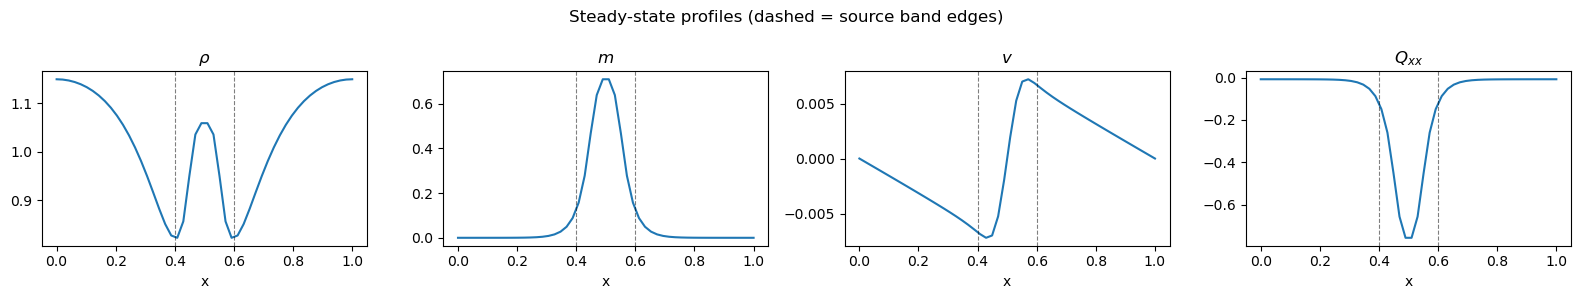

In [6]:
# Steady-state profiles
xc = data1d['x']
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (field, label) in zip(axes, [
    (data1d['rho'], r'$\rho$'),
    (data1d['m'],   r'$m$'),
    (data1d['v'],   r'$v$'),
    (data1d['Q'],   r'$Q_{xx}$'),
]):
    ax.plot(xc, field[-1])
    ax.set_xlabel('x')
    ax.set_title(label)
    ax.axvline(0.4, color='k', ls='--', lw=0.8, alpha=0.5)
    ax.axvline(0.6, color='k', ls='--', lw=0.8, alpha=0.5)

plt.suptitle('Steady-state profiles (dashed = source band edges)')
plt.tight_layout()
plt.show()

## 2D simulation

In [7]:
T   = 10
tau = 0.05

sim2d = MyosinActinGel2D(
    width=1, height=1, maxh=0.03,
    # mechanics
    gamma = 1.0,
    eta_1 = 1,
    eta_2 = 0.0,
    chi0  = 0.1,
    chi1  = 0.5,
    # nematic
    kappa = 1e-3,
    beta1 = 1.0,
    beta2 = 1.0,
    Qsq   = Qsq,
    # density / myosin
    S     = S,
    m0    = m0,
    k0    = 0.1,
    k1    = 1,
    k_m   = 1,
    D_rho = 1e-3,
    D_m   = 1e-3,
    # base
    k     = 0.5,
    D     = 1e-3,
    rho0  = 1.0,
)

sim2d.simulate(tend=T, tau=tau, save_interval=int(0.5/tau))
data2d = sim2d.export(n_samples=60)

  8%|▊         | 16/200 [00:00<00:02, 67.74it/s]

craete bilinearformapplication


100%|██████████| 200/200 [00:02<00:00, 87.48it/s]


/Users/yuli/Documents/Code/Cleavage/src/utils.py:122: RuntimeWarning: invalid value encountered in divide
  (vx / vmag)[::stride, ::stride].T,
/Users/yuli/Documents/Code/Cleavage/src/utils.py:123: RuntimeWarning: invalid value encountered in divide
  (vy / vmag)[::stride, ::stride].T,


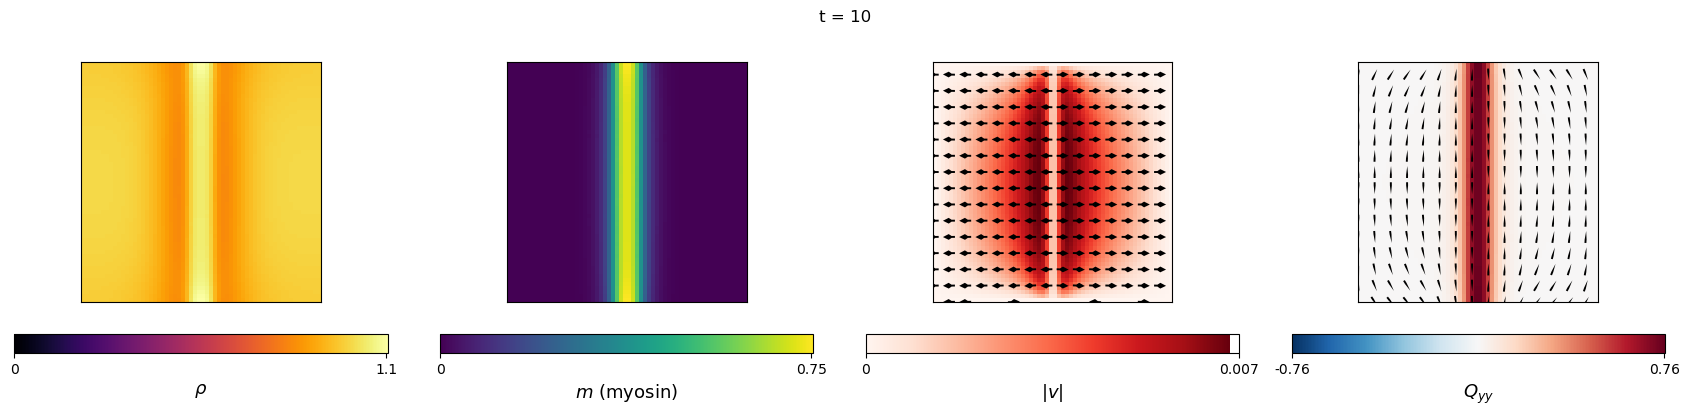

In [10]:
from utils import add_cbar, plot_2d_frame
plot_2d_frame(data2d, t=-1, title=f't = {T}')

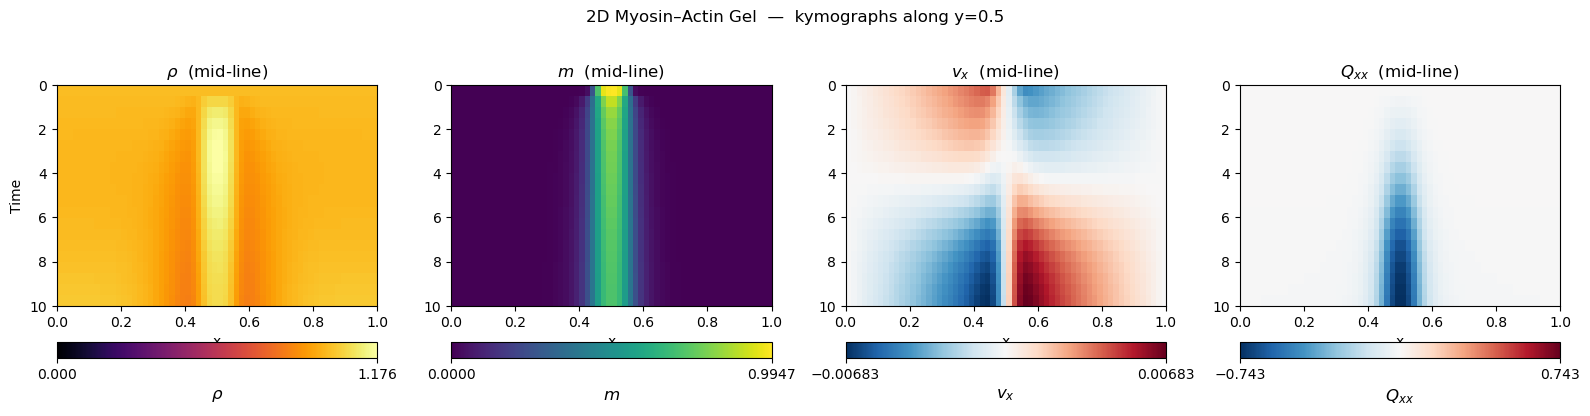

In [9]:
# Mid-line (y=0.5) profiles over time — same as 1D kymograph style
n = data2d['rho'].shape[2] // 2  # midline index

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fields = [
    (data2d['rho'][:, :, n], r'$\rho$',  'inferno'),
    (data2d['m'][:, :, n],   r'$m$',     'viridis'),
    (data2d['vx'][:, :, n],  r'$v_x$',   'RdBu_r'),
    (data2d['Q'][:, :, n],   r'$Q_{xx}$','RdBu_r'),
]
t_end = data2d['rho'].shape[0] * 0.5

for ax, (field, title, cmap) in zip(axes, fields):
    vmax = np.max(np.abs(field))
    vmin = -vmax if cmap == 'RdBu_r' else 0
    im = ax.imshow(field, aspect='auto', interpolation='none',
                   origin='upper', cmap=cmap, extent=(0, 1, t_end, 0),
                   vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, location='bottom', pad=0.12,
                 ticks=[vmin, vmax]).set_label(title, fontsize=12)
    ax.set_title(title + '  (mid-line)')
    ax.set_xlabel('x')

axes[0].set_ylabel('Time')
plt.suptitle('2D Myosin–Actin Gel  —  kymographs along y=0.5', y=1.02)
plt.tight_layout()
plt.show()